# CITS5508: Assignment 1
**Name:** James Wigfield 

**Student ID:** 23334375 

Semester 1, 2026

## Part 1: Softmax Regression

### 1.1 Data Loading and Exploration
in this section the MNIST dataset is loaded from OpenML using scikit-learn's 'fetch_openml'.

I then explore the dataset by printing basic statistics and visualising examples from the dataset to understand what features and labels look like before any modelling. 


In [54]:
from sklearn.datasets import fetch_openml
import numpy as np

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

#### Display Dataset Statistics
Here, various statistics about the dataset has been printed. We can see that the total number of samples in the dataset is **70,000**, **784** features (which are simply 28 x 28 pixels in each image) and **10** classes (0-9 digits).

We can also see the class distribution of the dataset which ranges from roughly **9%** to **11%** showing that the dataset is relatively well balanced.

In [55]:
# Basic dataset info
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

# Class distribution
unique, counts = np.unique(y, return_counts=True)
print("\nClass distribution:")
for digit, count in zip(unique, counts):
    print(f"  Digit {int(digit)}: {count} samples ({100*count/len(y):.2f}%)")

# Data type and value ranges
# print(f"\nData type: {X.dtype}")
print(f"Value range: [{X.min():.1f}, {X.max():.1f}]")
print(f"Mean pixel value: {X.mean():.2f}")
print(f"Std pixel value: {X.std():.2f}")

# Missing values
print(f"Missing values: {np.isnan(X).sum()}")

Dataset shape: X=(70000, 784), y=(70000,)
Number of samples: 70000
Number of features: 784
Number of classes: 10
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']

Class distribution:
  Digit 0: 6903 samples (9.86%)
  Digit 1: 7877 samples (11.25%)
  Digit 2: 6990 samples (9.99%)
  Digit 3: 7141 samples (10.20%)
  Digit 4: 6824 samples (9.75%)
  Digit 5: 6313 samples (9.02%)
  Digit 6: 6876 samples (9.82%)
  Digit 7: 7293 samples (10.42%)
  Digit 8: 6825 samples (9.75%)
  Digit 9: 6958 samples (9.94%)
Value range: [0.0, 255.0]
Mean pixel value: 33.39
Std pixel value: 78.65
Missing values: 0


#### Display Dataset Examples
Below, an example of each digit (class) from the dataset has been displayed. These are the first occurence of each in the dataset (*0 - 9*).

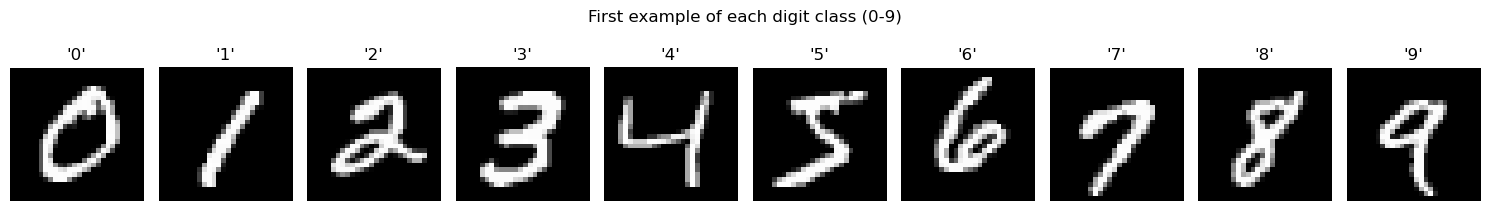

In [56]:
import matplotlib.pyplot as plt

# Display the first example of each digit class (0–9)
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for digit in range(10):
    idx = np.where(y == str(digit))[0][0]
    axes[digit].imshow(X[idx].reshape(28, 28), cmap='gray')
    axes[digit].set_title(f"'{digit}'")
    axes[digit].axis('off')
plt.suptitle('First example of each digit class (0-9)', y=1.05)
plt.tight_layout()
plt.show()

#### Display Dataset Heatmap
The below code block displays a heatmap for each digit in the dataset. The pixels that are "*hotter*" show regions where that digit was written out more than pixels that are slightly "*cooler*". An interesting observation is for the digit **2**, we can see from the heatmap that this dataset must include exampels of **2** that have been written with a *loop* at the bottom and also without. 

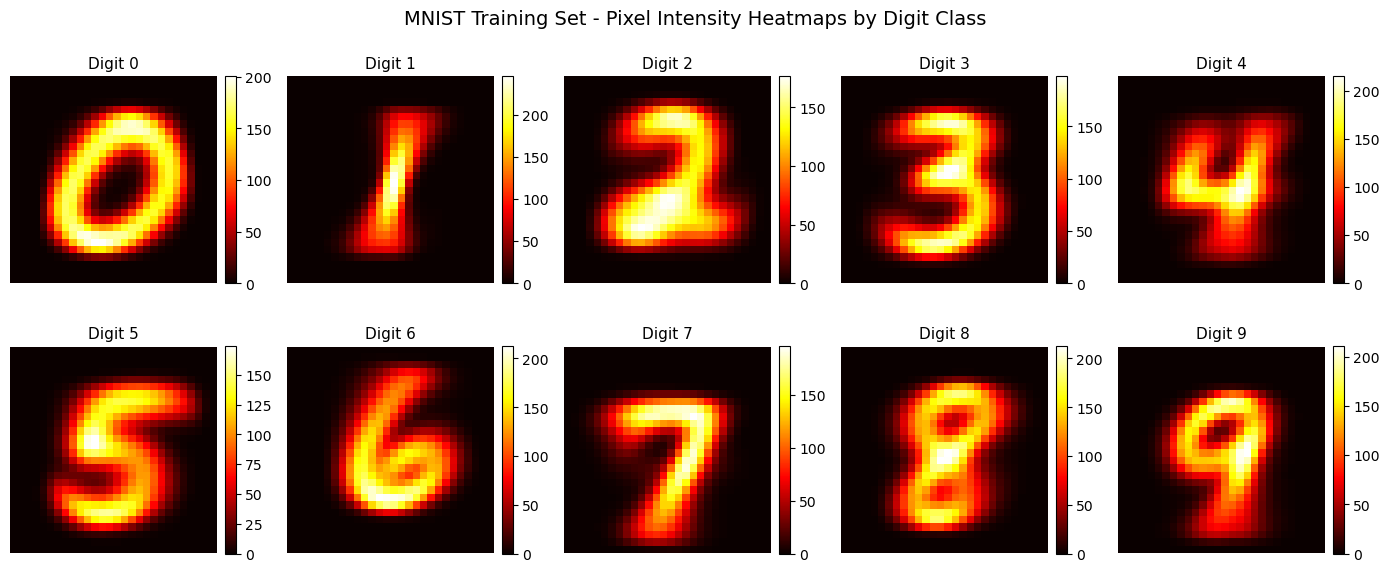

In [57]:
import matplotlib.pyplot as plt

# Display heatmaps for each digit class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for digit in range(10):
    # Find all indices where the label matches this digit
    indices = np.where(y == str(digit))[0]
    
    # Extract all images for this digit and reshape
    digit_images = X[indices].reshape(len(indices), 28, 28)
    
    # Average all images for this digit to create heatmap
    heatmap = np.mean(digit_images, axis=0)
    
    # Display as heatmap
    ax = axes[digit]
    im = ax.imshow(heatmap, cmap='hot')
    ax.set_title(f"Digit {digit}", fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('MNIST Training Set - Pixel Intensity Heatmaps by Digit Class', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


#### Dataset Description
The MNIST dataset is a famous dataset consisting of 70,000 greyscale images of handwritten digits (0-9). Some examples of what these images look like are displayed from the above code block (these are just the first 10 digits in the datset, not not ordered from 0 to 9). Each image is 28 x 28 pixels which have been flattened into a row of 784 features. Each of these features is simply a greyscale pixel intensity which is reporesented as an integer between 0 and 255. The labels are the digit that the image represets which are stored as strings '0' - '9'. 

### 1.2 Data Splitting
Here the MNIST samples have been split into three subsets:
- **Training set (70%)**: Used to learn the model parameters (weights) during fitting.  
- **Validation set (15%)**: Used during development to tune hyperparameters and monitor performance (e.g. early stopping) without touching test data.  
- **Test set (15%)**: Held out until final evaluation to provide an unbiased estimate of how well the model generalises to unseen data.

In [58]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the 30% evenly (15% val and test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation set: X_val={X_val.shape}, y_val={y_val.shape}")

Training set: X_train=(49000, 784), y_train=(49000,)
Validation set: X_val=(10500, 784), y_val=(10500,)


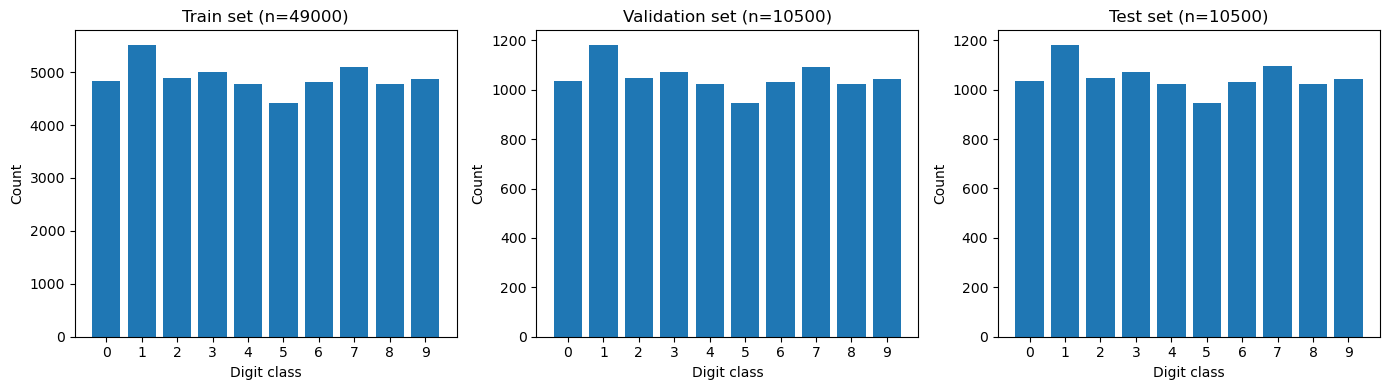

In [59]:
# Display Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]

for ax, (name, labels) in zip(axes, splits):
    classes, counts = np.unique(labels, return_counts=True)
    ax.bar(classes, counts)
    ax.set_title(f'{name} set (n={len(labels)})')
    ax.set_xlabel('Digit class')
    ax.set_ylabel('Count')
    ax.set_xticks(classes)

plt.tight_layout()
plt.show()

#### Stratification Justification
The dataset has been split into a Training (70%), Validation(15%) and Test (15%) set using *train_test_split*, however, this function doesn't support 3 way splits so it has been done in 2 stages. First split was a 70% train and 30% temporary split, then the temporary split was split evenly to give a 15% validation and 15% test set. 

As we can see from the class distribution from each set, there doesn't appear to be any major class imballance with only the digit class '1' appearing a few hundred more times, which is nothing major.  

**Stratification:** I set ```stratify=y``` to ensure that each split has the same class proportions as the whole dataset. Without stratification, since 1 is the most frequent class in MNIST (11.25%) and 5 is the least frequent (9.02%), these classes would likely be over/under represented in a completely random unstratified split. A completely random split could skew the training data toward *1's*, giving the model an unbalanced view of the problem. 

As the bar charts above confirm, the class distributions across train, validation, and test sets are near-identical, verifying that stratification has worked correctly.

### 1.3 Softmax Regression Implementation

Here we implement softmax regression from scratch using only NumPy. The model uses **mini-batch gradient descent** to minimise the cross-entropy loss, and applies **early stopping** based on the validation loss to prevent overfitting.

Before training, pixel values are normalised from [0, 255] to [0, 1] by dividing by 255. This is important since without scaling, the large raw pixel values produce extremely large dot products, causing numerical overflow in the softmax exponentials and making gradient descent would be unstable.

The core mathematics follow the provided formulas directly:
- The softmax function converts raw class scores into probabilities
- The cross-entropy loss measures how far predicted probabilities are from the true one-hot labels
- The gradient update nudges the weight matrix in the direction that reduces loss

In [67]:
#normalise pixel values to between [0, 1]
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

# softmax regression built from scratch
class SoftmaxRegression:

    def __init__(self, lr=0.1, max_epochs=1000, batch_size=256, patience=50,
                 print_every=100, random_state=42):
        self.lr = lr
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.print_every = print_every
        self.rng = np.random.default_rng(random_state)

    def _add_bias(self, X):
        #prepend a column of 1's so the bias is absorbed into W
        return np.c_[np.ones(X.shape[0]), X]

    def _softmax(self, Z):
        # subtract row max first to stop exp() overflowing (numerically stable trick)
        Z_shift = Z - Z.max(axis=1, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / exp_Z.sum(axis=1, keepdims=True)

    def _one_hot(self, y):
        # e.g. label '3' would be [0,0,0,1,0,0,0,0,0,0]
        indices = np.array([self.class_to_idx_[label] for label in y])
        Y = np.zeros((len(y), len(self.classes_)))
        Y[np.arange(len(y)), indices] = 1
        return Y

    def _cross_entropy(self, X_b, Y_oh):
        P = self._softmax(X_b @ self.W_)
        return -np.mean(np.sum(Y_oh * np.log(P + 1e-15), axis=1))

    def fit(self, X, y, X_val, y_val):
        self.classes_ = np.unique(y)
        self.class_to_idx_ = {c: i for i, c in enumerate(self.classes_)}

        X_b = self._add_bias(X)
        X_val_b = self._add_bias(X_val)
        Y_oh = self._one_hot(y)
        Y_val = self._one_hot(y_val)

        m, n = X_b.shape
        K = len(self.classes_)

        self.W_ = np.zeros((n, K))
        self.train_losses_ = []
        self.val_losses_ = []

        best_val_loss = np.inf
        best_W = self.W_.copy()
        best_epoch = 0
        no_improve = 0

        if self.print_every:
            w = len(str(self.max_epochs))
            print(f"{'Epoch':>{w + 7}}  {'train loss':>10}  {'val loss':>10}")
            print("-" * (w + 34))

        for epoch in range(self.max_epochs):
            # shuffle training data each epoch so mini-batches are different
            perm = self.rng.permutation(m)
            X_shuf = X_b[perm]
            Y_shuf = Y_oh[perm]

            for start in range(0, m, self.batch_size):
                Xb = X_shuf[start : start + self.batch_size]
                Yb = Y_shuf[start : start + self.batch_size]
                P = self._softmax(Xb @ self.W_)
                # vectorised gradient: (1/m) * X^T(P - Y) from the assignment formula
                grad = Xb.T @ (P - Yb) / len(Xb)
                self.W_ -= self.lr * grad

            train_loss = self._cross_entropy(X_b, Y_oh)
            val_loss = self._cross_entropy(X_val_b, Y_val)
            self.train_losses_.append(train_loss)
            self.val_losses_.append(val_loss)

            improved = val_loss < best_val_loss
            if improved:
                best_val_loss = val_loss
                best_W = self.W_.copy()
                best_epoch = epoch + 1
                no_improve = 0
            else:
                no_improve += 1

            if self.print_every and (epoch + 1) % self.print_every == 0:
                marker = " <-- best" if improved else ""
                print(f"  Epoch {epoch + 1:>{w}}/{self.max_epochs}  "
                      f"{train_loss:>10.4f}  {val_loss:>10.4f}{marker}")

            # stop early if val loss hasn't improved in 'patience' epochs
            if no_improve >= self.patience:
                print(f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.4f} at epoch {best_epoch})")
                break

        # restore best weights found during training
        self.W_ = best_W
        self.best_epoch_ = best_epoch
        self.n_epochs_run_ = len(self.train_losses_)
        return self

    def predict_proba(self, X):
        return self._softmax(self._add_bias(X) @ self.W_)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


#### Set Hyperparameters
Here you can set the hyperparameters used if you don't want to use default parameter values. I have found that the following hyperparamters seem to give the best results:
- **Learning Rate (lr):** 0.1
- **Max Epochs (max_epochs):** 500 (I set up to 1000 but with a patience of around 50 early stopping came into play each time anyway)
- **Mini Batch Size (batch_size):** 256
- **Patience/Early Stopping (patience):** 50 (I would not set this to any higher than 50, as long as it is not below 15 it will work well)


In [68]:
lr = 0.1
max_epochs = 1000
batch_size = 256
patience = 50

#### Run the Model
Here is where the model is run, make sure to run above code cell first to define hyperparameters. You can change ```print_every``` to change how many epoch iterations should run before printing the current *training* and *validation* accuracy. This is just to avoid printing after every epoch (which would roughly end up with around 180 lines).

In [69]:
model = SoftmaxRegression(lr=lr, max_epochs=max_epochs, batch_size=batch_size, patience=patience, print_every=20, random_state=42)
model.fit(X_train_norm, y_train, X_val_norm, y_val)

train_acc = np.mean(model.predict(X_train_norm) == y_train)
val_acc = np.mean(model.predict(X_val_norm) == y_val)
print(f"Epochs run: {model.n_epochs_run_}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")


      Epoch  train loss    val loss
--------------------------------------
  Epoch   20/1000      0.2865      0.3144 <-- best
  Epoch   40/1000      0.2672      0.3017 <-- best
  Epoch   60/1000      0.2586      0.2974 <-- best
  Epoch   80/1000      0.2528      0.2956 <-- best
  Epoch  100/1000      0.2494      0.2957
  Epoch  120/1000      0.2456      0.2934 <-- best
  Epoch  140/1000      0.2430      0.2949
  Epoch  160/1000      0.2410      0.2935
  Epoch  180/1000      0.2387      0.2936
Early stopping at epoch 181 (best val loss: 0.2933 at epoch 131)
Epochs run: 181
Train accuracy: 0.9330
Validation accuracy: 0.9199


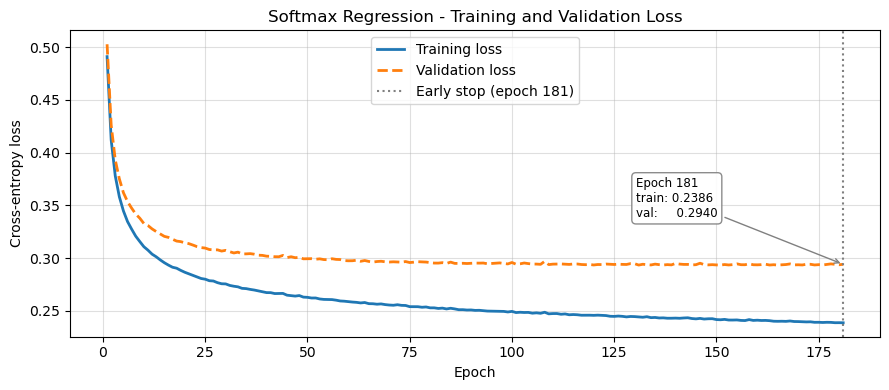

In [66]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(model.train_losses_) + 1)

ax.plot(epochs, model.train_losses_, label='Training loss', linewidth=2)
ax.plot(epochs, model.val_losses_, label='Validation loss', linewidth=2, linestyle='--')

# annotate the early-stopping epoch
stop_epoch = model.n_epochs_run_
stop_train = model.train_losses_[-1]
stop_val   = model.val_losses_[-1]

ax.axvline(stop_epoch, color='gray', linestyle=':', linewidth=1.5, label=f'Early stop (epoch {stop_epoch})')

# place the label to the left if there's not enough room on the right
n_epochs = len(model.train_losses_)
x_offset = -n_epochs * 0.28 if stop_epoch > n_epochs * 0.6 else n_epochs * 0.05
ax.annotate(
    f'Epoch {stop_epoch}\ntrain: {stop_train:.4f}\nval:     {stop_val:.4f}',
    xy=(stop_epoch, stop_val),
    xytext=(stop_epoch + x_offset, stop_val + 0.045),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='gray', alpha=0.9),
)

ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Softmax Regression - Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


#### Training Observations

Both the training and validation loss decrease steadily in the early epochs, which shows the model is actually learning rather than just memorising (if it were overfitting immediately it would be expect that validation loss would start rising early on while training loss kept dropping).

The training loss continued to fall throughout all 181 epochs (from 0.2865 at epoch 20 down to 0.2387 at epoch 180), while the validation loss improved much more slowly and essentially plateaued from around epoch 120 onwards, sitting around 0.293–0.294. The best validation loss of **0.2933** was recorded at **epoch 131** (which isn't actually visible in the printed output due to `print_every=20` but it was recorded). Early stopping then triggered at epoch 181, exactly 50 epochs of no improvement later, matching the `patience=50` setting.

The gap between training loss (~0.239) and validation loss (~0.293) at the end is noticeable but not alarming (roughly 0.05) which suggests there is *some* overfitting happening, but it's fairly mild. The accuracy numbers back this up: **93.3% train accuracy vs 92.0% validation accuracy**, a gap of only ~1.3%. For a model this simple (a linear classifier on raw pixels), I think this is a reasonable result and not a sign of a serious problem.

Early stopping worked as expected. Without it the model would have kept training for another 819 epochs past a validation loss that had already plateaued at epoch 131, wasting compute and risking further overfitting with no real benefit.

### 1.4 Scikit-Learn Logistic Regression Comparison

To validate the the model built from scratch it will be compared against scikit-learn's `LogisticRegression`, which uses the **L-BFGS** optimiser - a quasi-Newton second-order method that converges far more efficiently than gradient descent that was implemented. Set `penalty=None` to disable regularisation.

The comparison covers:
- Accuracy on training and test sets for both models
- Confusion matrices showing per-class error patterns on the test set
- Per-class precision, recall, and F1-score via `classification_report`

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# no regularisation (penalty=None) so comparison with custom model is fair
sklearn_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42)
sklearn_model.fit(X_train_norm, y_train)

print(f"{'Model':<30}  {'Train acc':>10}  {'Test acc':>10}")
print("-" * 56)
for name, clf in [('Custom Softmax Regression', model), ('sklearn LogisticRegression', sklearn_model)]:
    tr = accuracy_score(y_train, clf.predict(X_train_norm))
    te = accuracy_score(y_test, clf.predict(X_test_norm))
    print(f"{name:<30}  {tr:>10.4f}  {te:>10.4f}")


Model                            Train acc    Test acc
--------------------------------------------------------
Custom Softmax Regression           0.9330      0.9208
sklearn LogisticRegression          0.9453      0.9130


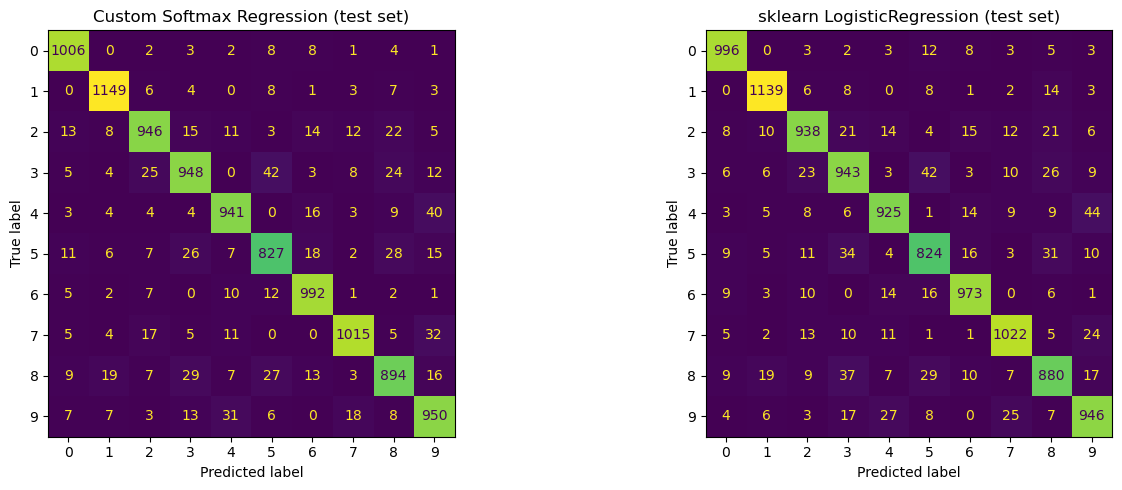

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, model.predict(X_test_norm),
    ax=axes[0], colorbar=False
)
axes[0].set_title('Custom Softmax Regression (test set)')

ConfusionMatrixDisplay.from_predictions(
    y_test, sklearn_model.predict(X_test_norm),
    ax=axes[1], colorbar=False
)
axes[1].set_title('sklearn LogisticRegression (test set)')

plt.tight_layout()
plt.show()


In [73]:
print("=== Custom Softmax Regression - Test Set ===")
print(classification_report(y_test, model.predict(X_test_norm), digits=4))

=== Custom Softmax Regression - Test Set ===
              precision    recall  f1-score   support

           0     0.9455    0.9720    0.9586      1035
           1     0.9551    0.9729    0.9639      1181
           2     0.9238    0.9018    0.9127      1049
           3     0.9054    0.8852    0.8952      1071
           4     0.9225    0.9189    0.9207      1024
           5     0.8864    0.8733    0.8798       947
           6     0.9315    0.9612    0.9461      1032
           7     0.9522    0.9278    0.9398      1094
           8     0.8913    0.8730    0.8821      1024
           9     0.8837    0.9108    0.8971      1043

    accuracy                         0.9208     10500
   macro avg     0.9197    0.9197    0.9196     10500
weighted avg     0.9207    0.9208    0.9206     10500



In [74]:
print("=== sklearn LogisticRegression - Test Set ===")
print(classification_report(y_test, sklearn_model.predict(X_test_norm), digits=4))

=== sklearn LogisticRegression - Test Set ===
              precision    recall  f1-score   support

           0     0.9495    0.9623    0.9559      1035
           1     0.9531    0.9644    0.9588      1181
           2     0.9160    0.8942    0.9050      1049
           3     0.8748    0.8805    0.8776      1071
           4     0.9177    0.9033    0.9104      1024
           5     0.8720    0.8701    0.8710       947
           6     0.9347    0.9428    0.9387      1032
           7     0.9350    0.9342    0.9346      1094
           8     0.8765    0.8594    0.8679      1024
           9     0.8899    0.9070    0.8984      1043

    accuracy                         0.9130     10500
   macro avg     0.9119    0.9118    0.9118     10500
weighted avg     0.9128    0.9130    0.9129     10500



#### Model Comparison & Evaluation

The first thing that stood out is that the custom model actually outperforms sklearn on the test set (**92.08% vs 91.30%**), despite sklearn achieving higher training accuracy (94.53% vs 93.30%). This is a bit counterintuitive at first, but it makes sense when you look at the train-test gap for each model: sklearn drops 3.23% from train to test, while the custom model only drops 1.22%. sklearn's L-BFGS optimiser is more powerful and drives the training loss lower, but without any regularisation (`penalty=None`) it seems to overfit the training set more. The custom model's early stopping effectively acted as implicit regularisation, which likely explains why it generalises slightly better.

**Hardest digit classes:** Both models struggled most with the same digits (**5** and **8**) had the lowest F1-scores across both models (custom: 0.8798, 0.8821 / sklearn: 0.8710, 0.8679). This isn't surprising since 5 and 8 share similar curved lines and are visually similar. Digit **3** was noticeably harder for sklearn (F1=0.8776) than for the custom model (F1=0.8952), although I'm not sure exactly why (possibly a side effect of the different optimisation paths).

**Easiest digit classes:** Both models performed best on digits **0**, **1**, and **6**, which tend to have more distinctive shapes. Digit 1 in particular scored F1=0.9639 (custom) and 0.9588 (sklearn) (it's a simple vertical stroke that's hard to confuse with most other digits).

**Overall:** The results are overall what I'd expect from two fundamentally linear classifiers on raw pixel data. Neither model can learn non-linear decision boundaries, so there's a ceiling on how well they can separate visually similar digit pairs. Getting ~92% accuracy with a from-scratch NumPy implementation is a reasonable outcome, and the fact it matches (and slightly beats) sklearn gives me confidence the implementation is correct.

## Part 2: Support Vector Machine Regression

### 2.1 Dataset Generation

Synthetic polynomial datasets were generated of the form of the form:

$$y = \sum_{k=0}^{n} a_k x^k + \varepsilon$$

where $x \in [-3, 3]$, coefficients $a_k \sim \mathcal{U}(0, 1)$, and noise $\varepsilon \sim \mathcal{N}(0, 1)$.

The function `generate_polynomial_dataset(degree, n_samples)` outlines this generation process. It is then verified visually using demo plots for degree = 1, 2, and 3, before generating the three full datasets (linear, quadratic, cubic) with train/test splits for use in the SVR experiments.

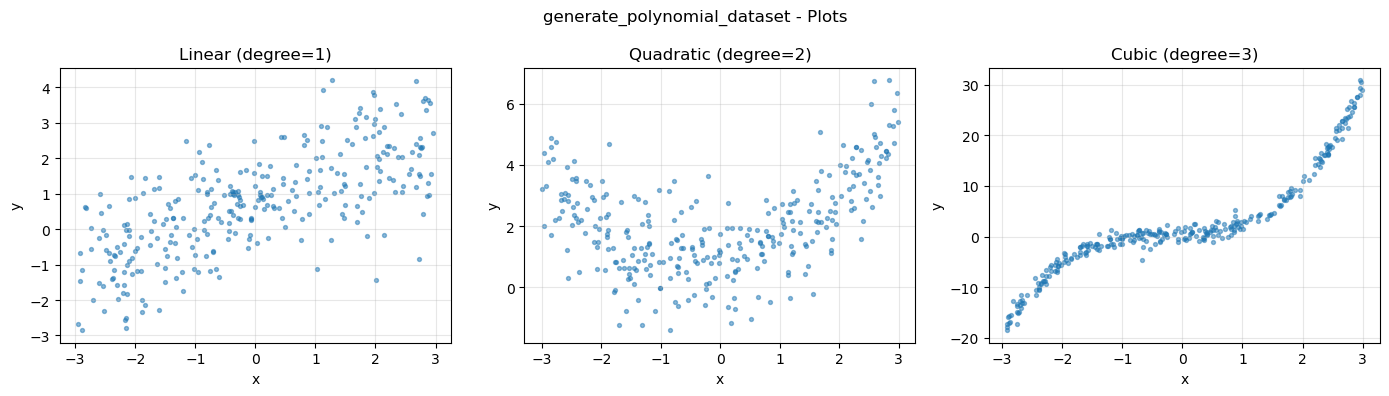

In [48]:
def generate_polynomial_dataset(degree, n_samples, random_state=42):
    rng = np.random.default_rng(random_state)
    x = rng.uniform(-3, 3, n_samples)
    # random coefficients a_0 ... a_degree, each from U(0,1)
    a = rng.uniform(0, 1, degree + 1)
    # y = sum(a_k * x^k) + noise, where noise ~ N(0,1)
    y = sum(a[k] * x**k for k in range(degree + 1)) + rng.standard_normal(n_samples)
    return x.reshape(-1, 1), y

# quick check - plot each degree to verify the function looks right
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [('Linear (degree=1)', 1, 10), ('Quadratic (degree=2)', 2, 20), ('Cubic (degree=3)', 3, 30)] 

for ax, (title, degree, seed) in zip(axes, configs):
    X_demo, y_demo = generate_polynomial_dataset(degree, n_samples=300, random_state=seed)
    ax.scatter(X_demo, y_demo, s=8, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)

plt.suptitle('generate_polynomial_dataset - Plots')
plt.tight_layout()
plt.show()


#### Create Splits and Visually Display Splits

3 datasets of 1000 samples (n=1000) each are generated (one per polynomial degree) using different random seeds so that the x values and coefficients are independent across datasets. Each is then split 80/20 into *training* and *test* sets.

The scatter plots below show the actual data used for modelling, with **training points in blue** and **test points in orange**. These are distinct from the small demo plots above (n=300) which were only used to verify the generator.

Dataset      Split      n     mean      std      min      max
--------------------------------------------------------------
Linear        train     800     0.264     1.886    -4.306     5.019
Linear        test      200     0.477     1.841    -3.590     5.014
Quadratic     train     800     0.367     1.050    -3.417     3.173
Quadratic     test      200     0.494     1.049    -2.432     3.278
Cubic         train     800     2.046     9.519   -23.494    26.785
Cubic         test      200     3.021    10.099   -20.583    27.232


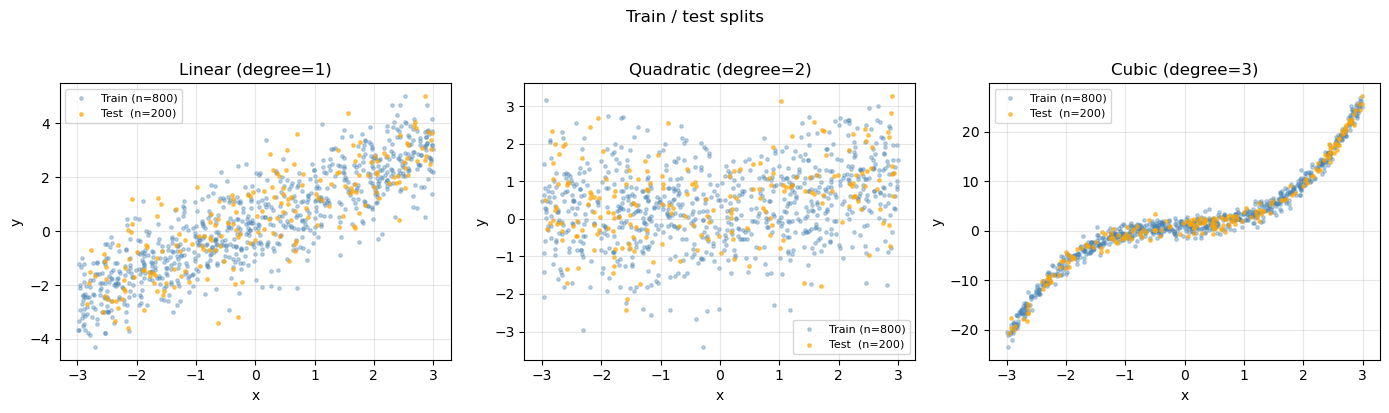

In [50]:
# different seeds so each dataset has independent x values and coefficients
X_lin, y_lin = generate_polynomial_dataset(degree=1, n_samples=1000, random_state=10)
X_quad, y_quad = generate_polynomial_dataset(degree=2, n_samples=1000, random_state=20)
X_cub, y_cub = generate_polynomial_dataset(degree=3, n_samples=1000, random_state=30)

# 80/20 train/test splits
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)
X_quad_train, X_quad_test, y_quad_train, y_quad_test = train_test_split(X_quad, y_quad, test_size=0.2, random_state=42)
X_cub_train, X_cub_test, y_cub_train, y_cub_test = train_test_split(X_cub, y_cub, test_size=0.2, random_state=42)

# summary stats per dataset
print(f"{'Dataset':<12} {'Split':<6} {'n':>5} {'mean':>8} {'std':>8} {'min':>8} {'max':>8}")
print("-" * 62)
for name, y_tr, y_te in [
    ('Linear', y_lin_train, y_lin_test),
    ('Quadratic', y_quad_train, y_quad_test),
    ('Cubic', y_cub_train, y_cub_test),
]:
    for split, y in [('train', y_tr), ('test', y_te)]:
        print(f"{name:<12}  {split:<6}  {len(y):>5}  {y.mean():>8.3f}  {y.std():>8.3f}  {y.min():>8.3f}  {y.max():>8.3f}")

# plot the actual train/test splits for all three datasets
# these are different from the demo plots above they use the real n=1000 data used for modelling
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
split_data = [
    ('Linear (degree=1)',    X_lin_train,  y_lin_train,  X_lin_test,  y_lin_test),
    ('Quadratic (degree=2)', X_quad_train, y_quad_train, X_quad_test, y_quad_test),
    ('Cubic (degree=3)',     X_cub_train,  y_cub_train,  X_cub_test,  y_cub_test),
]

for ax, (title, X_tr, y_tr, X_te, y_te) in zip(axes, split_data):
    ax.scatter(X_tr, y_tr, s=6, alpha=0.35, color='steelblue', label=f'Train (n={len(y_tr)})')
    ax.scatter(X_te, y_te, s=6, alpha=0.6,  color='orange',    label=f'Test  (n={len(y_te)})')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Train / test splits', y=1.02)
plt.tight_layout()
plt.show()


### 2.2 SVR with Different Kernels

The `sklearn.svm.SVR` models have been fitted using 3 kernels - `linear`, `poly`, and `rbf` - to each of the 3 synthetic datasets (linear, quadratic, and cubic). Each model is then wrapped in a `make_pipeline` with `StandardScaler` (since SVR is sensitive to input scale).

The 3x3 grid below shows the fitted regression curve against training and test data for all 9 kernel x dataset combinations. Test set R<sup>2</sup> is annotated on each subplot and summarised in a table below the figure.

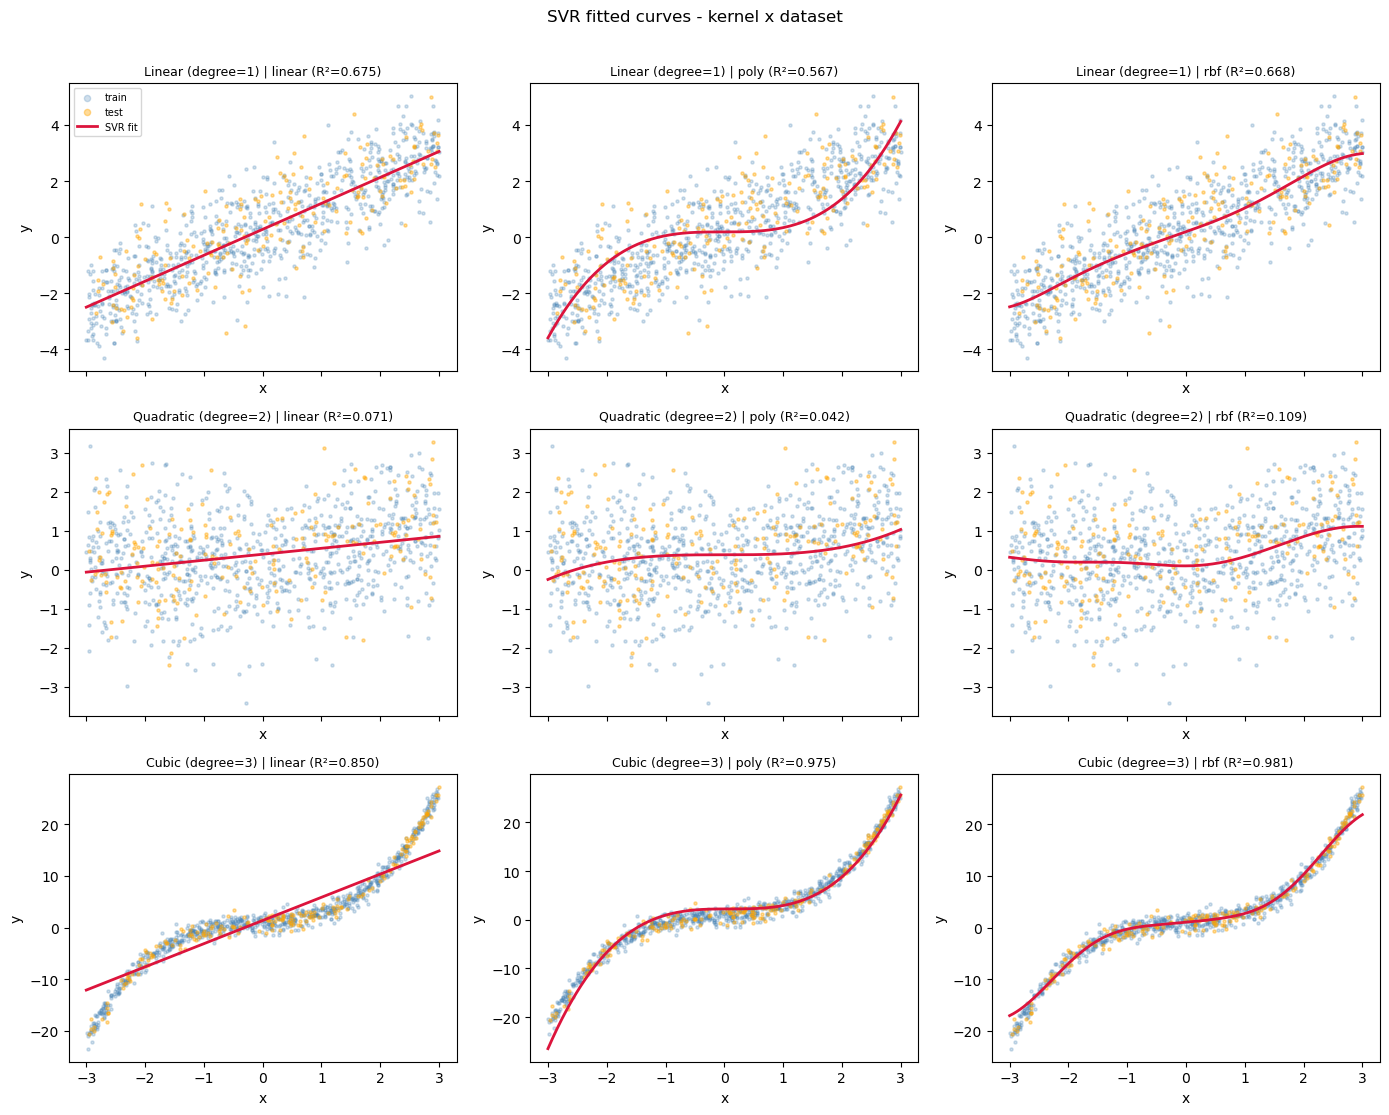

Dataset                    kernel=linear     kernel=poly      kernel=rbf
------------------------------------------------------------------------
Linear (degree=1)                 0.6753          0.5665          0.6676
Quadratic (degree=2)              0.0707          0.0421          0.1087
Cubic (degree=3)                  0.8497          0.9746          0.9806


In [51]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

kernels = ['linear', 'poly', 'rbf']
datasets = [
    ('Linear (degree=1)', X_lin_train, y_lin_train, X_lin_test, y_lin_test),
    ('Quadratic (degree=2)', X_quad_train, y_quad_train, X_quad_test, y_quad_test),
    ('Cubic (degree=3)', X_cub_train, y_cub_train, X_cub_test, y_cub_test),
]

x_grid = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)
svr_models = {}

for row, (name, X_tr, y_tr, X_te, y_te) in enumerate(datasets):
    for col, kernel in enumerate(kernels):
        ax = axes[row, col]
        # SVR is sensitive to feature scale, so StandardScaler is important
        svr = make_pipeline(StandardScaler(), SVR(kernel=kernel))
        svr.fit(X_tr, y_tr)
        svr_models[(name, kernel)] = svr

        r2 = svr.score(X_te, y_te)
        ax.scatter(X_tr, y_tr, s=5, alpha=0.25, color='steelblue', label='train')
        ax.scatter(X_te, y_te, s=5, alpha=0.4, color='orange', label='test')
        ax.plot(x_grid, svr.predict(x_grid), color='crimson', linewidth=2, label='SVR fit')
        ax.set_title(f'{name} | {kernel} (R²={r2:.3f})', fontsize=9)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        if row == 0 and col == 0:
            ax.legend(fontsize=7, markerscale=2)

plt.suptitle('SVR fitted curves - kernel x dataset', y=1.01)
plt.tight_layout()
plt.show()

# R-squared summary table
header = f"{'Dataset':<24}  " + '  '.join(f"{'kernel='+k:>14}" for k in kernels)
print(header)
print('-' * len(header))
for name, X_tr, y_tr, X_te, y_te in datasets:
    scores = [f"{svr_models[(name, k)].score(X_te, y_te):>14.4f}" for k in kernels]
    print(f"{name:<24}  " + '  '.join(scores))


#### Kernel Performance Analysis

Looking at the R² scores, the results are a bit surprising in places — particularly for the quadratic dataset.

**Linear kernel** performed reasonably on the linear data (R²=0.6753), which makes sense since it can only fit a straight line and the data actually is linear. It also did better than expected on the cubic data (R²=0.8497), which I didn't expect — I think this is because the cubic polynomial generated happened to have a strong overall upward trend, meaning a straight line still captures a reasonable amount of variance. On the quadratic data it essentially failed (R²=0.0707), which makes sense since a straight line can't capture the curved shape.

**Poly kernel** was the weakest on both linear and quadratic data (R²=0.5665 and 0.0421 respectively), which is a bit unexpected. I'd have thought it would handle quadratic data well, but I think the default degree=3 with the default SVR hyperparameters isn't tuning itself well to this particular dataset. It does however perform strongly on cubic data (R²=0.9746), where the polynomial kernel's flexibility clearly helps.

**RBF kernel** was fairly consistent across datasets — not the best on any single one, but rarely the worst. It performed similarly to linear on the linear data (R²=0.6676), and was the best of the three on quadratic (R²=0.1087), though all kernels struggled there. On cubic data it was the strongest (R²=0.9806). Overall RBF seems like the most reliable choice across dataset types, which aligns with it being the default recommended kernel for SVR in most situations.

The standout result is how badly all three kernels performed on the quadratic dataset. I suspect this comes down to the default hyperparameters — the quadratic data has a relatively narrow y range (roughly -3.4 to 3.3), so with `epsilon=0.1` and `C=1`, a large portion of the training points may fall inside the epsilon tube, leaving the model with too few support vectors to capture the curve shape properly. This is exactly why hyperparameter tuning matters, which is explored in the next section.

### 2.3 Hyperparameter Tuning via Grid Search

`GridSearchCV` was used with 5-fold cross-validation to search over 3 SVR hyperparameters on the **cubic dataset** (which is the most challenging of the 3).

The hyperparameters and their values are:

| Hyperparameter | values | What it controls |
|---|---|---|
| `kernel` | `poly`, `rbf` | How the input space is transformed |
| `C` | `1`, `100` | Regularisation (how much to penalise errors outside the ε-tube) |
| `epsilon` | `0.1`, `0.5` | Width of the ε-tube (points inside incur no loss) |

2 values × 2 values × 2 values = **8 combinations**, each evaluated with **5-fold CV** = **40 models** fitted in total.

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd

# grid over kernel type, regularisation C, and epsilon (tube width)
param_grid = {
    'svr__kernel': ['poly', 'rbf'],
    'svr__C': [1, 100],
    'svr__epsilon': [0.1, 0.5],
}

pipe = make_pipeline(StandardScaler(), SVR())
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipe, param_grid,
    cv=kf, scoring='r2',
    refit=True, n_jobs=-1,
)
grid_search.fit(X_cub_train, y_cub_train)

n_combos = len(grid_search.cv_results_['params'])
print(f'Hyperparameters: {list(param_grid.keys())}')
print(f'Combinations: {n_combos}')
print(f'Folds: 5')
print(f'Total models: {n_combos * 5}')
print(f'Best params: {grid_search.best_params_}')
print(f'Best CV R²: {grid_search.best_score_:.4f}')

# full results sorted by rank
cols = ['param_svr__kernel', 'param_svr__C', 'param_svr__epsilon','mean_test_score', 'std_test_score', 'rank_test_score']

results_df = (pd.DataFrame(grid_search.cv_results_)[cols]
              .rename(columns={
                  'param_svr__kernel': 'kernel',
                  'param_svr__C': 'C',
                  'param_svr__epsilon': 'epsilon',
                  'mean_test_score': 'mean R²',
                  'std_test_score': 'std R²',
                  'rank_test_score': 'rank',
              })
              .sort_values('rank')
              .reset_index(drop=True))
print()
print(results_df.to_string(index=False, float_format='{:.4f}'.format))


Hyperparameters: ['svr__kernel', 'svr__C', 'svr__epsilon']
Combinations: 8
Folds: 5
Total models: 40
Best params: {'svr__C': 100, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf'}
Best CV R²: 0.9885

kernel   C  epsilon  mean R²  std R²  rank
   rbf 100   0.1000   0.9885  0.0021     1
   rbf 100   0.5000   0.9884  0.0020     2
   rbf   1   0.1000   0.9759  0.0020     3
   rbf   1   0.5000   0.9756  0.0022     4
  poly   1   0.5000   0.9661  0.0090     5
  poly 100   0.5000   0.9660  0.0091     6
  poly   1   0.1000   0.9656  0.0093     7
  poly 100   0.1000   0.9653  0.0095     8


#### Grid Search Results

**Hyperparameters chosen:** `kernel`, `C`, and `epsilon` (all 3 directly control how SVR fits the data). `kernel` determines the shape the model can fit (polynomial vs radial basis). `C` is the regularisation parameter (a high C means the model is penalised more for points outside the epsilon tube) so it tries harder to fit the training data closely. `epsilon` controls the width of the tube itself (points inside it contribute no loss) so a smaller epsilon makes the model more sensitive to errors. Together these 3 cover the most impactful levers for SVR performance, which is why I chose them.

**Total models fitted:** 8 combinations × 5 folds = **40 models**, plus one final refit of the best configuration on the full training set.

**Best result:** `rbf` kernel with `C=100` and `epsilon=0.1`, achieving a CV R² of **0.9885**. This wasn't too surprising given the kernel analysis above showed RBF was the strongest on cubic data even with default settings (giving it a higher C and tighter epsilon tube just pushed it further). The high C makes sense here because the cubic dataset has a wide y range, so letting the model penalise outliers more aggressively helps it track the curve shape.

**RBF vs poly:** All four RBF combinations ranked above all 4 poly combinations, which is a clear pattern. The poly kernel's R² values (~0.966) are still decent, but the higher std R² (up to 0.0095 vs 0.0021 for RBF) shows the poly results are less stable across folds (suggesting it's more sensitive to which particular subset of training data it sees).

**epsilon had little effect:** The difference between `epsilon=0.1` and `epsilon=0.5` within the same kernel and C was tiny (e.g. 0.9885 vs 0.9884 for RBF, C=100). For this dataset the choice of kernel and C mattered far more than the tube width.

### 2.4 Optimal Model Evaluation

We evaluate the best model found by the grid search on the held-out test set. This gives an unbiased estimate of performance on data the model has never seen (neither during training or during cross-validation).

Best params:    {'svr__C': 100, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf'}
CV R² (train):  0.9885
Test R²:        0.9903


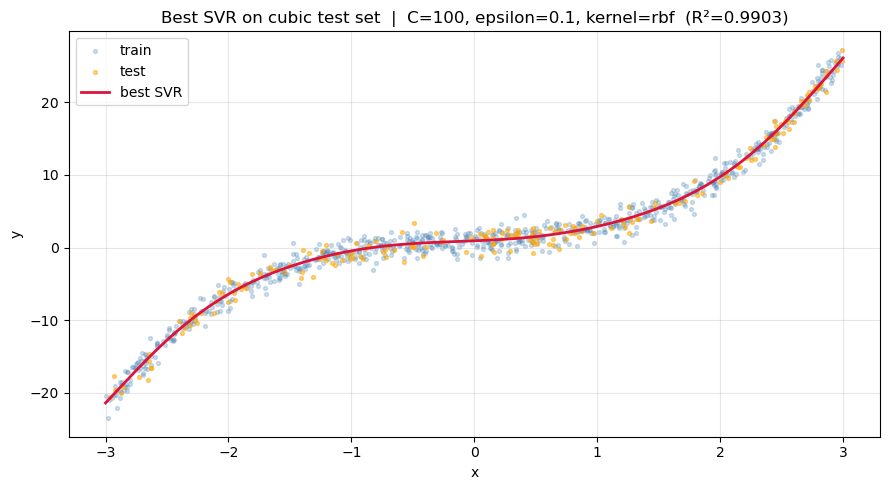

In [75]:
best_model = grid_search.best_estimator_
test_r2 = best_model.score(X_cub_test, y_cub_test)

print(f'Best params:    {grid_search.best_params_}')
print(f'CV R² (train):  {grid_search.best_score_:.4f}')
print(f'Test R²:        {test_r2:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_cub_train, y_cub_train, s=8, alpha=0.25, color='steelblue', label='train')
ax.scatter(X_cub_test, y_cub_test, s=8, alpha=0.5, color='orange', label='test')
ax.plot(x_grid, best_model.predict(x_grid), color='crimson', linewidth=2, label='best SVR')
params_str = ', '.join(f'{k.replace("svr__","")}={v}' for k, v in grid_search.best_params_.items())
ax.set_title('Best SVR on cubic test set  |  ' + params_str + f'  (R²={test_r2:.4f})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Final Conclusion

In this assignment, two separate machine learning tasks were completed:
- multiclass classification on MNIST using softmax regression 
- regression on synthetic polynomial data using SVR.

**Part 1** showed that a softmax regression model built entirely from scratch using NumPy can get surprisingly close to sklearn's optimised `LogisticRegression`. The custom model achieved ~92.1% test accuracy vs ~91.3% for sklearn, which was actually slightly better (likely because early stopping acted as a form of implicit regularisation that prevented the model from overfitting the training set as much). The confusion matrices for both models showed the same hard digit pairs (5/8 and 3/8 being the most confused), which makes sense given that both are fundamentally linear classifiers operating on the same feature space.

**Part 2** demonstrated how much kernel choice and hyperparameter tuning matter for SVR. With default settings, performance was mixed (particularly on the quadratic dataset where all three kernels struggled due to the narrow y range relative to the default epsilon tube width). After grid search on the cubic dataset, the best model (`rbf`, `C=100`, `epsilon=0.1`) achieved a CV R² of **0.9885** and a test R² that was nearly identical, which is a good sign (this means the model wasn't just fitting noise in the training folds and generalised well to the held-out test set).
